# NFL Formation Analysis
## Red Zone Formation Analysis

This notebook analyzes offensive formation and personnel usage inside the opponent's 20 yard line — the red zone. Red zone efficiency is one of the most important factors separating winning and losing teams, and formation selection plays a critical role in determining whether drives end in touchdowns or field goals.

---

### Setup & Data Load

In [1]:
%pip install matplotlib seaborn pandas==2.2.2 --prefer-binary


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


---

### Imports & Data Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(project_root, "data", "processed")
figures_path = os.path.join(project_root, "outputs", "figures")

all_plays = pd.read_parquet(os.path.join(processed_path, "all_plays.parquet"))

# Filter to red zone plays (inside opponent 20)
red_zone = all_plays[all_plays['yardline_100'] <= 20].copy()

print(f"Total red zone plays: {len(red_zone):,}")
print(f"\nPlay type breakdown:\n{red_zone['play_type'].value_counts()}")
print(f"\nFormation breakdown:\n{red_zone['offense_formation'].value_counts()}")
print(f"\nTouchdown rate: {red_zone['touchdown'].mean():.2%}")

Total red zone plays: 52,084

Play type breakdown:
play_type
pass    27550
run     24534
Name: count, dtype: int64

Formation breakdown:
offense_formation
SHOTGUN         28051
SINGLEBACK       8191
UNDER CENTER     5473
EMPTY            3278
I_FORM           2816
PISTOL           1953
JUMBO            1667
WILDCAT           292
Name: count, dtype: int64

Touchdown rate: 19.76%


52,084 red zone plays across 10 seasons with a 19.76% touchdown rate. Key observations:

- **Pass and run are nearly equal in the red zone** — 27,550 passes vs 24,534 runs, much more balanced than the full dataset where passes dominate 60/40
- **Shotgun still leads formation usage (28,051 — 54%)** but its dominance is smaller than the full dataset
- **Jumbo formation usage increases significantly** in the red zone — 1,667 plays vs its minimal use elsewhere, reflecting its short yardage value
- **Under Center increases to 11%** from its 9% league-wide rate, confirming teams shift toward traditional formations near the goal line

---

### Touchdown Rate by Formation
Which formations score touchdowns most efficiently in the red zone?

offense_formation  plays   avg_epa  td_rate  success_rate
            JUMBO   1667  0.132398 0.492501      0.543491
     UNDER CENTER   5473  0.017100 0.207382      0.453864
          WILDCAT    292  0.045080 0.205479      0.503425
            EMPTY   3278  0.097338 0.201037      0.420988
          SHOTGUN  28051  0.028546 0.190296      0.415172
       SINGLEBACK   8191  0.019109 0.178244      0.437920
           PISTOL   1953 -0.001801 0.164363      0.428059
           I_FORM   2816 -0.007858 0.164062      0.424716


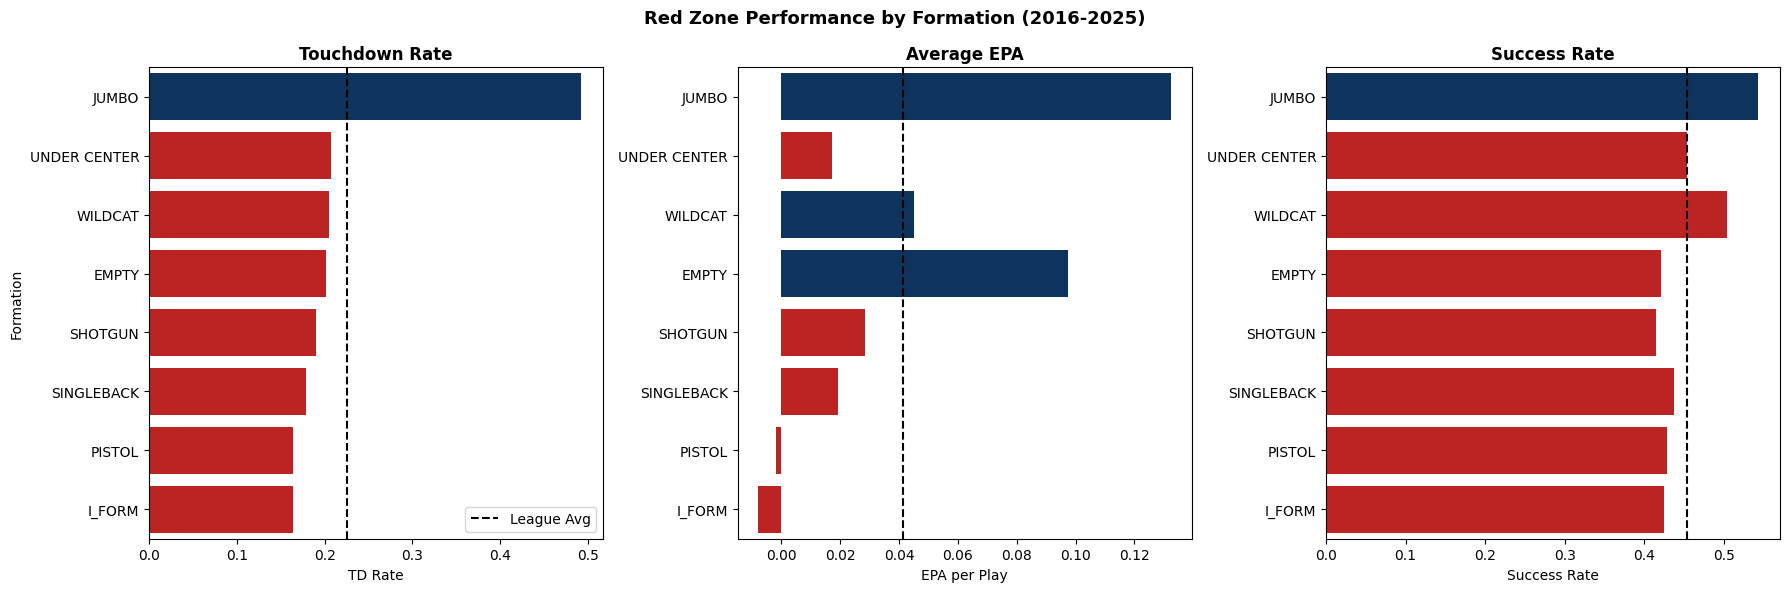

In [3]:
# Red zone TD rate and EPA by formation
rz_formation = red_zone.groupby('offense_formation').agg(
    plays=('epa', 'count'),
    avg_epa=('epa', 'mean'),
    td_rate=('touchdown', 'mean'),
    success_rate=('success', 'mean')
).reset_index()

rz_formation = rz_formation[rz_formation['plays'] >= 100].sort_values('td_rate', ascending=False)

print(rz_formation.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

league_avg_td = rz_formation['td_rate'].mean()
colors = ['#013369' if x >= league_avg_td else '#D50A0A' for x in rz_formation['td_rate']]

# TD rate
sns.barplot(data=rz_formation, x='td_rate', y='offense_formation',
            hue='offense_formation',
            palette=dict(zip(rz_formation['offense_formation'], colors)),
            legend=False, ax=axes[0])
axes[0].axvline(x=league_avg_td, color='black', linestyle='--', linewidth=1.5, label='League Avg')
axes[0].set_title('Touchdown Rate', fontweight='bold')
axes[0].set_xlabel('TD Rate')
axes[0].set_ylabel('Formation')
axes[0].legend()

# EPA
colors_epa = ['#013369' if x >= rz_formation['avg_epa'].mean() else '#D50A0A' for x in rz_formation['avg_epa']]
sns.barplot(data=rz_formation, x='avg_epa', y='offense_formation',
            hue='offense_formation',
            palette=dict(zip(rz_formation['offense_formation'], colors_epa)),
            legend=False, ax=axes[1])
axes[1].axvline(x=rz_formation['avg_epa'].mean(), color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Average EPA', fontweight='bold')
axes[1].set_xlabel('EPA per Play')
axes[1].set_ylabel('')

# Success rate
sns.barplot(data=rz_formation, x='success_rate', y='offense_formation',
            hue='offense_formation',
            palette=dict(zip(rz_formation['offense_formation'], colors)),
            legend=False, ax=axes[2])
axes[2].axvline(x=rz_formation['success_rate'].mean(), color='black', linestyle='--', linewidth=1.5)
axes[2].set_title('Success Rate', fontweight='bold')
axes[2].set_xlabel('Success Rate')
axes[2].set_ylabel('')

plt.suptitle('Red Zone Performance by Formation (2016-2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "red_zone_formation.png"), dpi=150, bbox_inches='tight')
plt.show()

![Red Zone Formation Performance](../outputs/figures/red_zone_formation.png)

The red zone formation data delivers one of the clearest and most actionable findings in this project:

**Red zone performance by formation:**
| Formation | Plays | TD Rate | Avg EPA | Success Rate |
|---|---|---|---|---|
| Jumbo | 1,667 | 49% | +0.132 | 54% |
| Under Center | 5,473 | 21% | +0.017 | 45% |
| Wildcat | 292 | 21% | +0.045 | 50% |
| Empty | 3,278 | 20% | +0.097 | 42% |
| Shotgun | 28,051 | 19% | +0.029 | 42% |
| Singleback | 8,191 | 18% | +0.019 | 44% |
| Pistol | 1,953 | 16% | -0.002 | 43% |
| I-Form | 2,816 | 16% | -0.008 | 42% |

**Jumbo is the dominant red zone formation by every metric:**
- **49% touchdown rate** — more than double the league average of 22%
- **+0.132 EPA** — the highest of any formation in the red zone
- **54% success rate** — the highest of any formation

**The gap between Jumbo and everything else is enormous.** A 49% TD rate vs 19-21% for Shotgun and Under Center means teams using Jumbo in the red zone score touchdowns at roughly 2.5x the rate of teams using Shotgun.

**Empty backfield is surprisingly strong (+0.097 EPA, 20% TD rate)** — forcing defenses into pure pass coverage creates mismatches near the goal line.

**I-Form and Pistol go negative in the red zone** — traditional formations that work well in the open field struggle when the field compresses and defenses can key on the run.

**The most important finding:** Jumbo is used on only 1,667 red zone plays out of 52,084 total — just 3.2% of red zone snaps. Given its 49% touchdown rate, it is dramatically underutilized. If teams ran Jumbo on even 10% of red zone plays instead of 3%, the data suggests it would meaningfully increase scoring rates.

---

### Red Zone Performance by Yard Line
How does formation effectiveness change as teams get closer to the goal line?

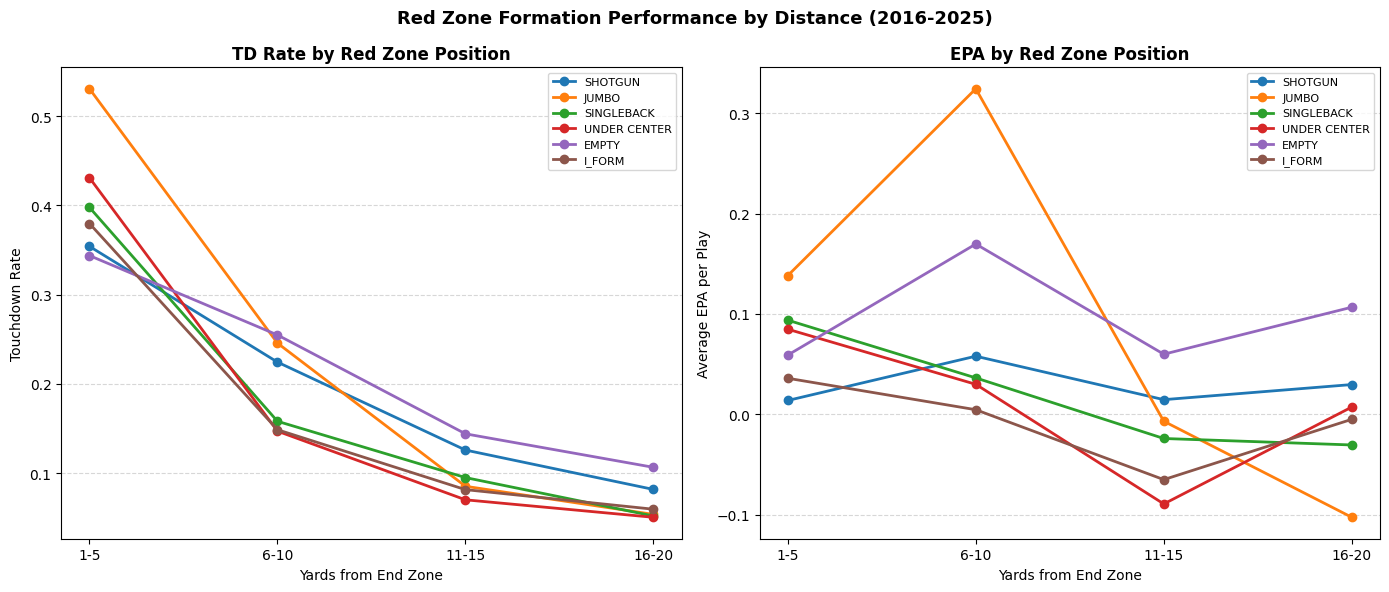

In [4]:
# Red zone performance by yard line zone
red_zone['rz_zone'] = pd.cut(
    red_zone['yardline_100'],
    bins=[0, 5, 10, 15, 20],
    labels=['1-5', '6-10', '11-15', '16-20']
)

zone_formation = red_zone.groupby(['rz_zone', 'offense_formation'], observed=True).agg(
    plays=('epa', 'count'),
    td_rate=('touchdown', 'mean'),
    avg_epa=('epa', 'mean')
).reset_index()

# Filter to main formations with enough sample
main_rz_formations = ['SHOTGUN', 'JUMBO', 'SINGLEBACK', 'UNDER CENTER', 'EMPTY', 'I_FORM']
zone_formation = zone_formation[
    zone_formation['offense_formation'].isin(main_rz_formations) &
    (zone_formation['plays'] >= 30)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# TD rate by zone
for formation in main_rz_formations:
    data = zone_formation[zone_formation['offense_formation'] == formation]
    if len(data) > 0:
        axes[0].plot(data['rz_zone'].astype(str), data['td_rate'], 
                    marker='o', linewidth=2, label=formation)

axes[0].set_title('TD Rate by Red Zone Position', fontweight='bold')
axes[0].set_xlabel('Yards from End Zone')
axes[0].set_ylabel('Touchdown Rate')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# EPA by zone
for formation in main_rz_formations:
    data = zone_formation[zone_formation['offense_formation'] == formation]
    if len(data) > 0:
        axes[1].plot(data['rz_zone'].astype(str), data['avg_epa'],
                    marker='o', linewidth=2, label=formation)

axes[1].set_title('EPA by Red Zone Position', fontweight='bold')
axes[1].set_xlabel('Yards from End Zone')
axes[1].set_ylabel('Average EPA per Play')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Red Zone Formation Performance by Distance (2016-2025)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "red_zone_by_distance.png"), dpi=150, bbox_inches='tight')
plt.show()

![Red Zone Formation by Distance](../outputs/figures/red_zone_by_distance.png)

The distance chart reveals how formation effectiveness changes dramatically as teams approach the goal line:

**TD rate trends by distance:**
- **Jumbo starts strong at 54% from 1-5 yards** then drops sharply to 25% at 6-10 yards — it is specifically a goal line formation, not a general red zone tool
- **All formations converge between 11-20 yards** — from further out in the red zone, formation matters less and play execution matters more
- **Empty backfield maintains the most consistent TD rate** across all distances, suggesting it is effective throughout the red zone not just near the goal line
- **Under Center and I-Form decline the fastest** as distance increases — they are pure short yardage formations that lose effectiveness when the field opens up slightly

**EPA trends by distance:**
- **Jumbo peaks at 6-10 yards (+0.330)** — the sweet spot where the run threat is most dangerous and defenses haven't fully committed to stopping it
- **Empty backfield is remarkably consistent** across all distances, maintaining positive EPA from 16 yards out all the way to the goal line
- **Shotgun is the most stable formation** — modest positive EPA at every distance, never excelling but never collapsing

**The tactical recommendation:** Use Jumbo from 1-10 yards, Empty from 11-20 yards, and Shotgun as the safe default throughout. I-Form and Under Center add little value beyond 5 yards from the end zone.

---

### Red Zone Personnel vs Coverage Matrix
Which personnel packages work best against specific coverages in the red zone?

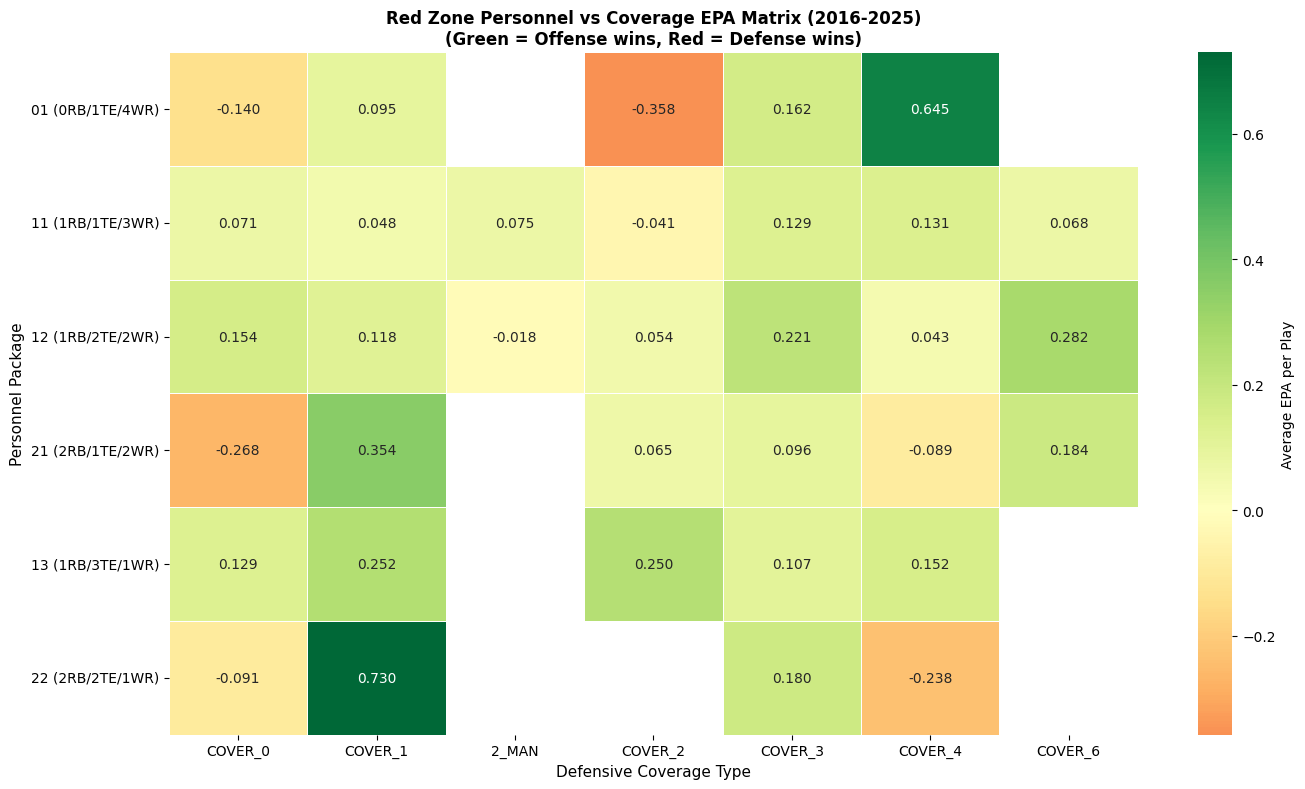

In [5]:
# Red zone personnel vs coverage matrix
main_coverages = ['COVER_0', 'COVER_1', 'COVER_2', 'COVER_3', 'COVER_4', 'COVER_6', '2_MAN']
top_personnel = ['11 (1RB/1TE/3WR)', '12 (1RB/2TE/2WR)', '21 (2RB/1TE/2WR)',
                 '13 (1RB/3TE/1WR)', '22 (2RB/2TE/1WR)', '01 (0RB/1TE/4WR)']

rz_personnel = red_zone[
    red_zone['personnel_package'].isin(top_personnel) &
    red_zone['defense_coverage_type'].isin(main_coverages)
]

rz_epa_matrix = rz_personnel.groupby(
    ['personnel_package', 'defense_coverage_type']
)['epa'].mean().reset_index()

rz_pivot = rz_epa_matrix.pivot(
    index='personnel_package',
    columns='defense_coverage_type',
    values='epa'
)

rz_count = rz_personnel.groupby(
    ['personnel_package', 'defense_coverage_type']
).size().reset_index(name='count')

rz_count_pivot = rz_count.pivot(
    index='personnel_package',
    columns='defense_coverage_type',
    values='count'
)

coverage_order = ['COVER_0', 'COVER_1', '2_MAN', 'COVER_2', 'COVER_3', 'COVER_4', 'COVER_6']
personnel_order = ['01 (0RB/1TE/4WR)', '11 (1RB/1TE/3WR)', '12 (1RB/2TE/2WR)',
                   '21 (2RB/1TE/2WR)', '13 (1RB/3TE/1WR)', '22 (2RB/2TE/1WR)']

rz_pivot = rz_pivot.reindex(index=personnel_order, columns=coverage_order)
rz_count_pivot = rz_count_pivot.reindex(index=personnel_order, columns=coverage_order)
mask_rz = rz_count_pivot < 20

plt.figure(figsize=(14, 8))
sns.heatmap(
    rz_pivot,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    mask=mask_rz,
    linewidths=0.5,
    annot_kws={'size': 10},
    cbar_kws={'label': 'Average EPA per Play'}
)
plt.title('Red Zone Personnel vs Coverage EPA Matrix (2016-2025)\n(Green = Offense wins, Red = Defense wins)',
          fontsize=12, fontweight='bold')
plt.xlabel('Defensive Coverage Type', fontsize=11)
plt.ylabel('Personnel Package', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "red_zone_personnel_coverage.png"), dpi=150, bbox_inches='tight')
plt.show()

![Red Zone Personnel vs Coverage Matrix](../outputs/figures/red_zone_personnel_coverage.png)

The red zone personnel vs coverage matrix reveals some of the most extreme matchup advantages in the entire project — the compressed field amplifies both successes and failures:

**Key matchup findings:**

**01 personnel (0RB/1TE/4WR):**
- Extraordinary against Cover 4 (+0.645) — quarters coverage in the red zone leaves receivers wide open
- Terrible against Cover 2 (-0.358) — two deep safeties with underneath help shuts down empty sets near the goal line
- High variance package — elite upside, significant downside

**11 personnel (1RB/1TE/3WR):**
- The most consistent package in the red zone — never goes deeply negative
- Best against Cover 3 (+0.129) and Cover 4 (+0.131)
- The safe, reliable red zone choice

**12 personnel (1RB/2TE/2WR):**
- Excellent against Cover 6 (+0.282) and Cover 3 (+0.221)
- Struggles against 2 Man (-0.018) — extra tight ends don't help against tight man coverage

**21 personnel (2RB/1TE/2WR):**
- Dominates Cover 1 (+0.354) — man coverage struggles against two backs and multiple receiving threats
- Gets destroyed by Cover 0 (-0.268) — all-out blitz overwhelms two-back sets

**22 personnel (2RB/2TE/1WR):**
- The highest single value cell in the matrix — +0.730 against Cover 1
- 22 personnel against man coverage in the red zone is essentially unstoppable
- Negative against Cover 0 (-0.091) and Cover 4 (-0.238)

**13 personnel (1RB/3TE/1WR):**
- Consistently positive across all coverages — never goes deeply negative
- Best against Cover 2 (+0.250) and Cover 1 (+0.252)
- The most blitz-proof heavy package in the red zone

**The single most actionable finding:** 22 personnel against Cover 1 generates +0.730 EPA in the red zone — the highest value matchup in the entire project. When defenses call man coverage inside the 20, two backs and two tight ends is the answer.

---

### Summary
This notebook reveals that red zone formation selection has an outsized impact on scoring efficiency:

1. **Jumbo scores touchdowns on 49% of plays** — more than double the league average, yet used on only 3% of red zone snaps
2. **Empty backfield is the most consistent formation** throughout the red zone, maintaining positive EPA at every distance
3. **22 personnel vs Cover 1 generates +0.730 EPA** — the highest value matchup in the entire project
4. **Formation effectiveness changes by distance** — Jumbo peaks at 1-10 yards, Empty is best from 11-20 yards
5. **Cover 2 is the best red zone defense** — it shuts down empty sets and limits big plays near the goal line